# Radiación electromagnética de cargas aceleradas: simulación angular, tiempo retardado y límite relativista

Este notebook es una investigación computacional breve para Electrodinámica II. No existe solo para producir figuras de una presentación: explora numéricamente patrones angulares, beaming relativista, tiempo retardado y contenido espectral simplificado.

Referencias físicas principales: Schwinger/Milton, *Classical Electrodynamics*, caps. 34, 35, 38 y 41--43.

## 1. Preparación

Usamos unidades normalizadas con $c=1$. Las constantes globales se omiten cuando solo interesan patrones relativos. La fórmula angular relativista se evalúa con vectores adimensionales $\boldsymbol\beta=\mathbf v/c$ y $\dot{\boldsymbol\beta}=\mathbf a/c$.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "font.size": 10,
})

def gamma_from_beta(beta):
    return 1 / np.sqrt(1 - np.asarray(beta)**2)

def angular_power(n, beta_vec, beta_dot_vec):
    beta_vec = np.asarray(beta_vec, dtype=float)
    beta_dot_vec = np.asarray(beta_dot_vec, dtype=float)
    ndotb = np.einsum("...i,i->...", n, beta_vec)
    inner = np.cross(n - beta_vec, beta_dot_vec)
    outer = np.cross(n, inner)
    numerator = np.sum(outer**2, axis=-1)
    denominator = np.maximum(1 - ndotb, 1e-12)**5
    return numerator / denominator

def spherical_grid(n_theta=160, n_phi=320):
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2*np.pi, n_phi)
    TH, PH = np.meshgrid(theta, phi, indexing="ij")
    n = np.stack([np.sin(TH)*np.cos(PH), np.sin(TH)*np.sin(PH), np.cos(TH)], axis=-1)
    return TH, PH, n

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches="tight")

## 2. Marco teórico mínimo

La solución retardada dice que el campo observado en $(\mathbf r,t)$ depende de la fuente en el tiempo $t_r$:

$$t_r = t - \frac{|\mathbf r-\mathbf r_q(t_r)|}{c}.$$

Para una carga acelerada, la parte radiativa del campo cae como $1/R$ y transporta energía. La distribución angular relativista, hasta factores constantes, puede escribirse como

$$\frac{dP}{d\Omega}\propto \frac{|\mathbf n	imes[(\mathbf n-\boldsymbol\beta)	imes\dot{\boldsymbol\beta}]|^2}{(1-\mathbf n\cdot\boldsymbol\beta)^5}.$$

Esta fórmula permite comparar directamente régimen no relativista, intermedio y relativista.

## 3. Distribución angular 3D

Tomamos un instante de movimiento circular: $\boldsymbol\beta$ apunta en $x$ y $\dot{\boldsymbol\beta}$ en $y$. La superficie no representa una frontera física: su radio codifica intensidad angular normalizada.

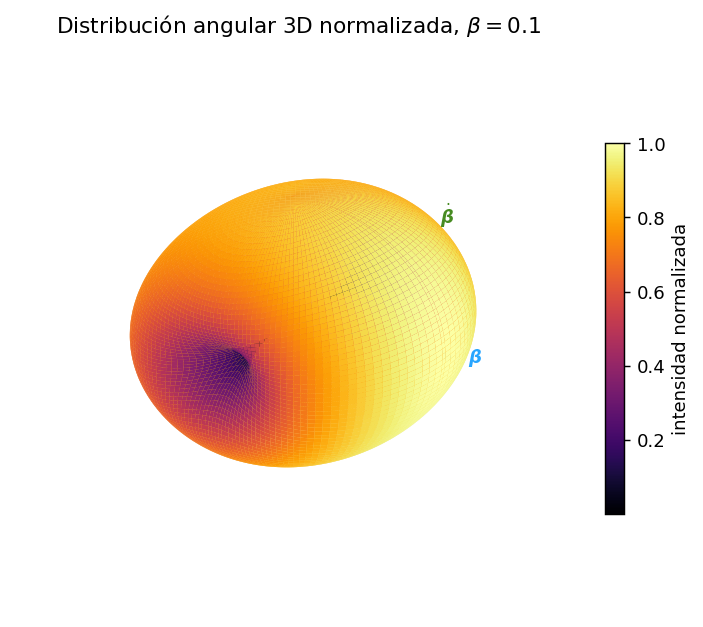

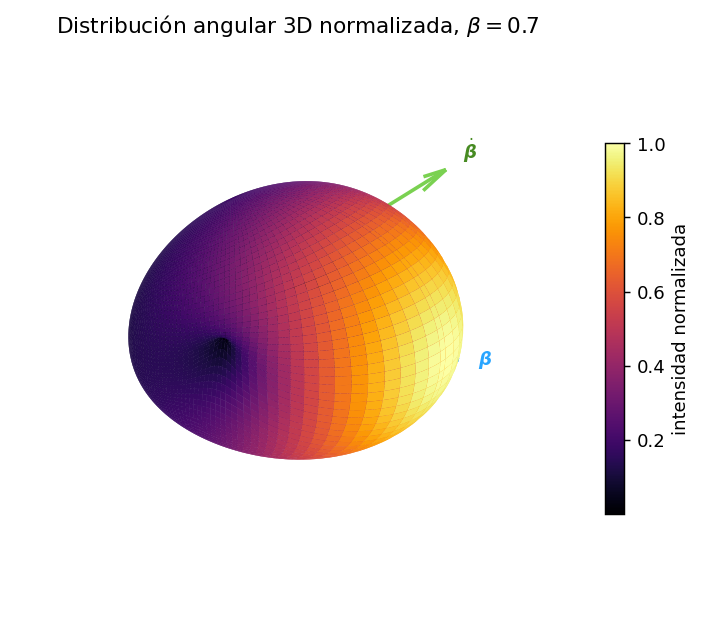

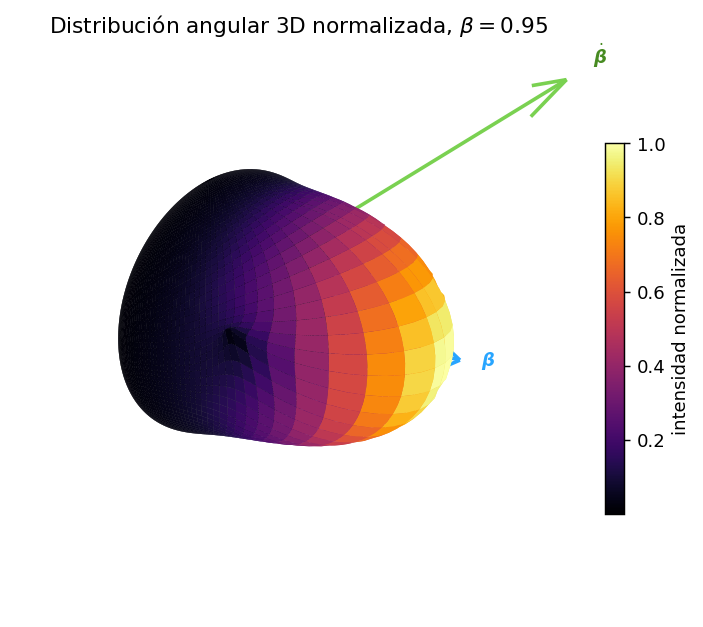

In [2]:
TH, PH, ngrid = spherical_grid()

def plot_angular_surface(beta, filename):
    P = angular_power(ngrid, [beta, 0, 0], [0, 1, 0])
    Pn = P / P.max()
    radius = 0.18 + Pn**0.35
    X = radius * np.sin(TH) * np.cos(PH)
    Y = radius * np.sin(TH) * np.sin(PH)
    Z = radius * np.cos(TH)
    fig = plt.figure(figsize=(7.2, 5.7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, facecolors=cm.inferno(Pn**0.45), rstride=2, cstride=2, linewidth=0, antialiased=True, shade=False)
    ax.quiver(0, 0, 0, 1.25, 0, 0, color="#28a5ff", linewidth=2, arrow_length_ratio=0.12)
    ax.text(1.35, 0, 0, r"$\boldsymbol{\beta}$", color="#28a5ff")
    ax.quiver(0, 0, 0, 0, 1.1, 0, color="#7ad151", linewidth=2, arrow_length_ratio=0.12)
    ax.text(0, 1.2, 0, r"$\dot{\boldsymbol{\beta}}$", color="#478b22")
    ax.set_title(fr"Distribución angular 3D normalizada, $\beta={beta}$")
    ax.set_axis_off()
    ax.view_init(elev=24, azim=-58)
    mappable = cm.ScalarMappable(cmap="inferno")
    mappable.set_array(Pn)
    fig.colorbar(mappable, ax=ax, shrink=0.65, pad=0.03, label="intensidad normalizada")
    savefig(filename)
    plt.show()

for beta, filename in [(0.10, "angular_3d_beta_010.png"), (0.70, "angular_3d_beta_070.png"), (0.95, "angular_3d_beta_095.png")]:
    plot_angular_surface(beta, filename)

## 4. Comparación angular: mapas y cortes polares

El mapa de calor permite ver dónde se concentra la intensidad en la esfera. El corte polar en el plano orbital muestra cómo el lóbulo principal se estrecha al aumentar $\beta$.

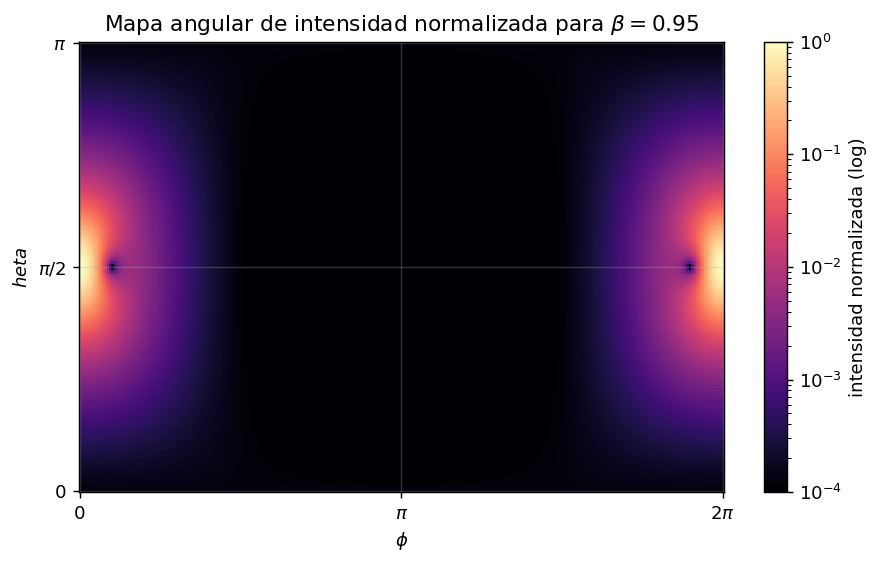

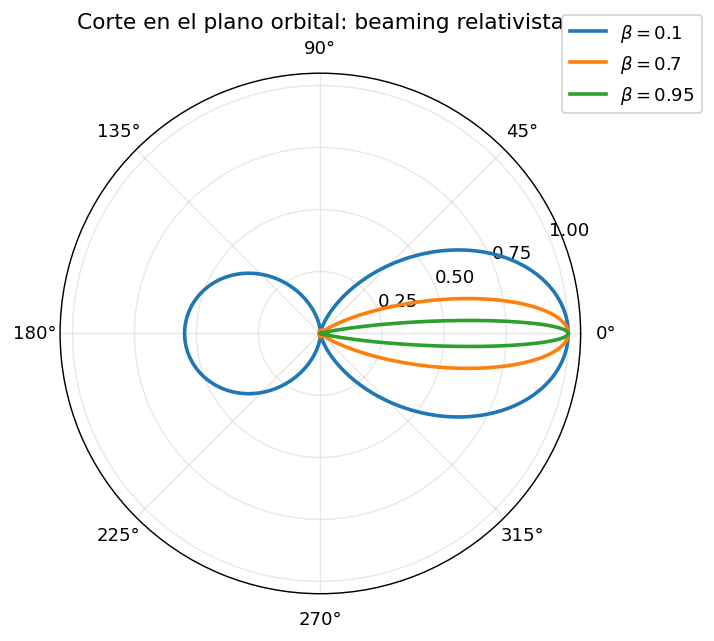

In [3]:
P95 = angular_power(ngrid, [0.95, 0, 0], [0, 1, 0])
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.pcolormesh(PH, TH, P95/P95.max(), shading="auto", cmap="magma", norm=LogNorm(vmin=1e-4, vmax=1))
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$	heta$")
ax.set_title(r"Mapa angular de intensidad normalizada para $\beta=0.95$")
ax.set_yticks([0, np.pi/2, np.pi]); ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels(["0", r"$\pi$", r"$2\pi$"])
fig.colorbar(im, ax=ax, label="intensidad normalizada (log)")
savefig("angular_heatmap_beta_095.png")
plt.show()

phi = np.linspace(0, 2*np.pi, 1440)
nplane = np.stack([np.cos(phi), np.sin(phi), np.zeros_like(phi)], axis=-1)
fig = plt.figure(figsize=(6.2, 5.2))
ax = fig.add_subplot(111, projection="polar")
for beta in [0.1, 0.7, 0.95]:
    P = angular_power(nplane, [beta, 0, 0], [0, 1, 0])
    ax.plot(phi, P/P.max(), lw=2, label=fr"$\beta={beta}$")
ax.set_theta_zero_location("E")
ax.set_title("Corte en el plano orbital: beaming relativista")
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.13))
savefig("polar_beaming_comparison.png")
plt.show()

## 5. Barrido paramétrico en $\beta$ y $\gamma$

Ahora cuantificamos tres efectos: crecimiento de $\gamma$, crecimiento relativo de potencia para radio fijo, aumento de la intensidad máxima angular y reducción del ancho del lóbulo principal. El ancho se estima numéricamente como FWHM del corte polar.

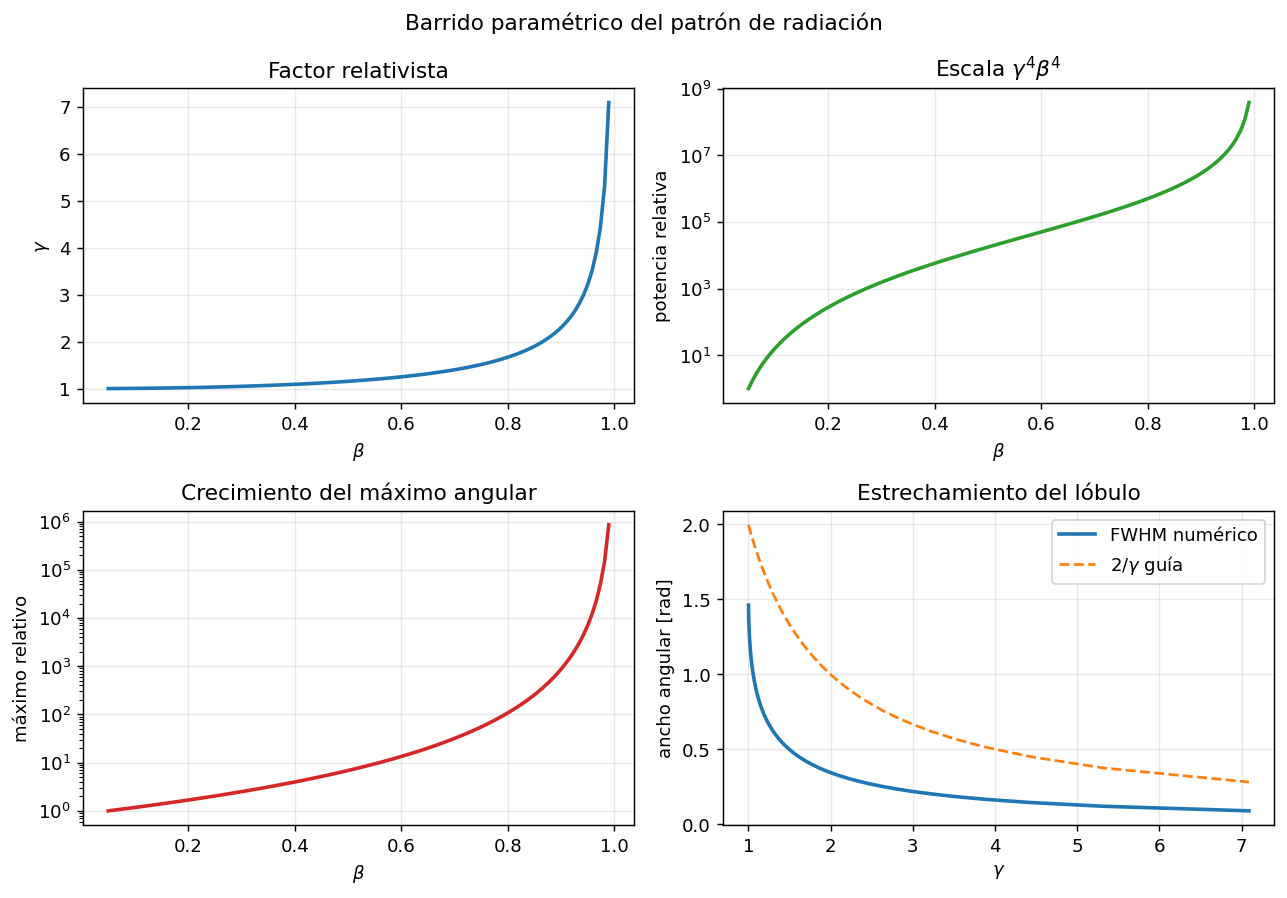

In [4]:
def fwhm_width(beta):
    P = angular_power(nplane, [beta, 0, 0], [0, 1, 0])
    Pn = P/P.max()
    i0 = int(np.argmax(Pn))
    d = np.angle(np.exp(1j*(phi - phi[i0])))
    mask = np.abs(d) < np.pi/2
    xs = np.abs(d[mask]); ys = Pn[mask]
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    below = np.where(ys < 0.5)[0]
    if len(below) == 0:
        return np.nan
    j = below[0]
    x1, x2 = xs[j-1], xs[j]
    y1, y2 = ys[j-1], ys[j]
    return 2*(x1 + (0.5-y1)*(x2-x1)/(y2-y1))

betas = np.linspace(0.05, 0.99, 120)
gammas = gamma_from_beta(betas)
max_intensity = np.array([angular_power(nplane, [b, 0, 0], [0, 1, 0]).max() for b in betas])
max_intensity /= max_intensity[0]
widths = np.array([fwhm_width(b) for b in betas])
relative_power = gammas**4 * betas**4
relative_power /= relative_power[0]

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs[0,0].plot(betas, gammas, lw=2); axs[0,0].set_xlabel(r"$\beta$"); axs[0,0].set_ylabel(r"$\gamma$"); axs[0,0].set_title("Factor relativista")
axs[0,1].semilogy(betas, relative_power, lw=2, color="tab:green"); axs[0,1].set_xlabel(r"$\beta$"); axs[0,1].set_ylabel("potencia relativa"); axs[0,1].set_title(r"Escala $\gamma^4\beta^4$")
axs[1,0].semilogy(betas, max_intensity, lw=2, color="tab:red"); axs[1,0].set_xlabel(r"$\beta$"); axs[1,0].set_ylabel("máximo relativo"); axs[1,0].set_title("Crecimiento del máximo angular")
axs[1,1].plot(gammas, widths, lw=2, label="FWHM numérico"); axs[1,1].plot(gammas, 2/gammas, "--", label=r"$2/\gamma$ guía"); axs[1,1].set_xlabel(r"$\gamma$"); axs[1,1].set_ylabel("ancho angular [rad]"); axs[1,1].set_title("Estrechamiento del lóbulo"); axs[1,1].legend()
fig.suptitle("Barrido paramétrico del patrón de radiación")
fig.tight_layout()
savefig("beta_parameter_sweep.png")
plt.show()

## 6. Movimiento circular como modelo computacional de sincrotrón

Para una trayectoria $\mathbf r(t)=R(\cos\omega t,\sin\omega t,0)$ se tiene $\beta=R\omega/c$ y $\gamma=(1-\beta^2)^{-1/2}$. Un estimador clásico de escala espectral es la frecuencia crítica angular

$$\omega_c \simeq \frac{3}{2}\gamma^3\omega.$$

No estamos haciendo un cálculo completo de sincrotrón: usamos este modelo para conectar curvatura, aceleración y escala espectral característica.

beta = 0.80
gamma = 1.667
radio de curvatura R = 1.0 en unidades normalizadas
frecuencia orbital omega = 0.800 c/R
frecuencia crítica aproximada omega_c = 5.556 c/R


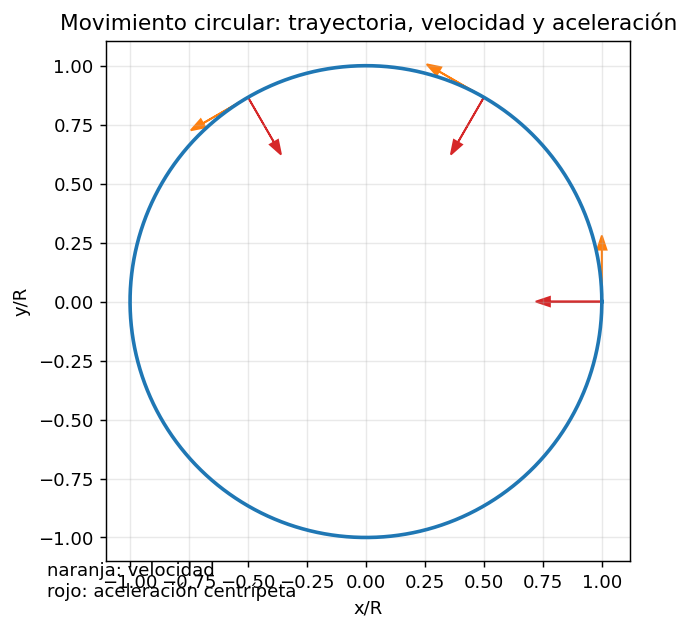

In [5]:
R = 1.0
beta_model = 0.8
omega = beta_model/R
gamma_model = gamma_from_beta(beta_model)
omega_c = 1.5 * gamma_model**3 * omega
print(f"beta = {beta_model:.2f}")
print(f"gamma = {gamma_model:.3f}")
print(f"radio de curvatura R = {R:.1f} en unidades normalizadas")
print(f"frecuencia orbital omega = {omega:.3f} c/R")
print(f"frecuencia crítica aproximada omega_c = {omega_c:.3f} c/R")

t = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.plot(np.cos(t), np.sin(t), lw=2)
for ti in [0, np.pi/3, 2*np.pi/3]:
    pos = np.array([np.cos(ti), np.sin(ti)])
    vel = np.array([-np.sin(ti), np.cos(ti)])
    acc = -pos
    ax.arrow(*pos, *(0.28*vel), head_width=0.04, color="tab:orange", length_includes_head=True)
    ax.arrow(*pos, *(0.28*acc), head_width=0.04, color="tab:red", length_includes_head=True)
ax.set_aspect("equal"); ax.set_xlabel("x/R"); ax.set_ylabel("y/R")
ax.set_title("Movimiento circular: trayectoria, velocidad y aceleración")
ax.text(-1.35, -1.25, "naranja: velocidad\nrojo: aceleración centrípeta")
savefig("circular_motion_vectors.png")
plt.show()

## 7. Tiempo retardado numérico

Resolvemos la ecuación implícita

$$t_r=t_{obs}-|\mathbf r_{obs}-\mathbf r_q(t_r)|/c$$

por bisección. Esto conecta directamente con potenciales retardados: la posición que influye en el observador no es la posición actual, sino la posición de la carga en $t_r$.

La demora absoluta está dominada por la distancia geométrica al observador. Para ver el efecto dinámico conviene separar dos cantidades: el cambio de demora respecto a un caso lento de referencia y el desfase angular efectivo $\Delta\phi=\omega(t_{obs}-t_r)$ sin envolver módulo $2\pi$.

<>:44: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:44: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_69931/2736298909.py:44: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axs[1].set_title("Desfase angular sin ambigüedad de $2\pi$")


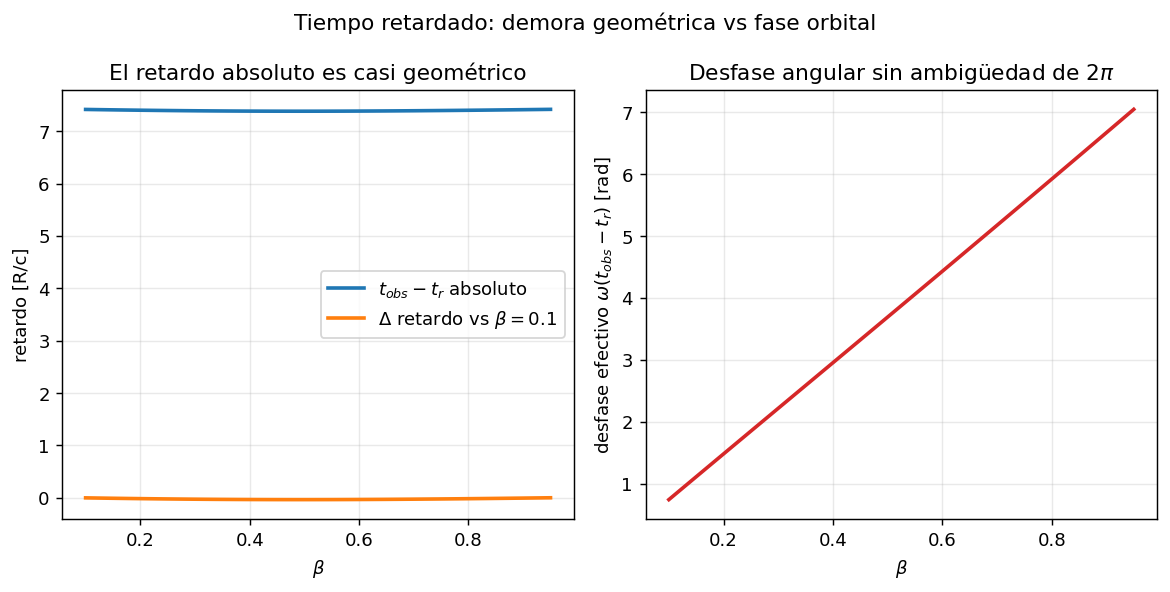

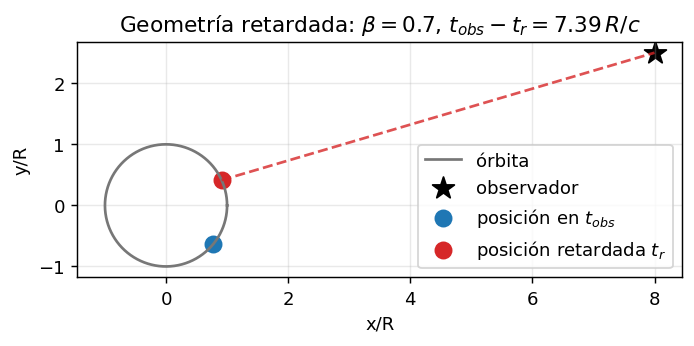

In [6]:
def rq_circular(t, beta=0.7, R=1.0):
    omega = beta/R
    return np.array([R*np.cos(omega*t), R*np.sin(omega*t), 0.0])

def retarded_time_bisect(t_obs, r_obs, beta=0.7, R=1.0, tol=1e-11, max_iter=100):
    def f(tr):
        return tr + np.linalg.norm(r_obs - rq_circular(tr, beta, R)) - t_obs
    hi = t_obs
    lo = t_obs - np.linalg.norm(r_obs) - R - 10*R/max(beta, 1e-3)
    while f(lo) > 0:
        lo -= 2*abs(lo-hi) + 1
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        if f(mid) <= 0:
            lo = mid
        else:
            hi = mid
        if abs(hi-lo) < tol:
            break
    return 0.5*(lo+hi)

obs = np.array([8.0, 2.5, 0.0])
t_obs = 8.0
ret_data = []
for b in np.linspace(0.1, 0.95, 80):
    tr = retarded_time_bisect(t_obs, obs, b)
    now = rq_circular(t_obs, b)
    old = rq_circular(tr, b)
    delay = t_obs - tr
    phase_lag = b * delay  # omega = beta/R and R=1 in normalized units
    ret_data.append((b, gamma_from_beta(b), delay, phase_lag))
ret_data = np.array(ret_data)

fig, axs = plt.subplots(1, 2, figsize=(9.1, 4.6))
axs[0].plot(ret_data[:,0], ret_data[:,2], lw=2, label=r"$t_{obs}-t_r$ absoluto")
axs[0].plot(ret_data[:,0], ret_data[:,2] - ret_data[0,2], lw=2, label=r"$\Delta$ retardo vs $\beta=0.1$")
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel("retardo [R/c]")
axs[0].set_title("El retardo absoluto es casi geométrico")
axs[0].legend(loc="best")
axs[1].plot(ret_data[:,0], ret_data[:,3], lw=2, color="tab:red")
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"desfase efectivo $\omega(t_{obs}-t_r)$ [rad]")
axs[1].set_title("Desfase angular sin ambigüedad de $2\pi$")
fig.suptitle("Tiempo retardado: demora geométrica vs fase orbital")
fig.tight_layout()
savefig("retarded_time_vs_beta.png")
plt.show()

b = 0.7
tr = retarded_time_bisect(t_obs, obs, b)
now = rq_circular(t_obs, b)
old = rq_circular(tr, b)
fig, ax = plt.subplots(figsize=(6,5.5))
ax.plot(np.cos(t), np.sin(t), color="#777", lw=1.5, label="órbita")
ax.scatter([obs[0]], [obs[1]], marker="*", s=160, color="black", label="observador")
ax.scatter([now[0]], [now[1]], s=80, color="tab:blue", label=r"posición en $t_{obs}$")
ax.scatter([old[0]], [old[1]], s=80, color="tab:red", label=r"posición retardada $t_r$")
ax.plot([old[0], obs[0]], [old[1], obs[1]], "--", color="tab:red", alpha=0.8)
ax.set_aspect("equal"); ax.set_xlabel("x/R"); ax.set_ylabel("y/R")
ax.set_title(fr"Geometría retardada: $\beta={b}$, $t_{{obs}}-t_r={t_obs-tr:.2f}\,R/c$")
ax.legend(loc="best")
savefig("retarded_position_geometry.png")
plt.show()

## 8. Análisis espectral simplificado

Una señal observada de una carga relativista en movimiento circular llega en pulsos estrechos cuando el haz apunta cerca del observador. Para ilustrar el efecto, usamos una señal periódica proporcional a $(1-\boldsymbol\beta\cdot\mathbf n)^{-3}$ y calculamos su FFT. Al aumentar $\beta$, aparecen armónicos más altos.

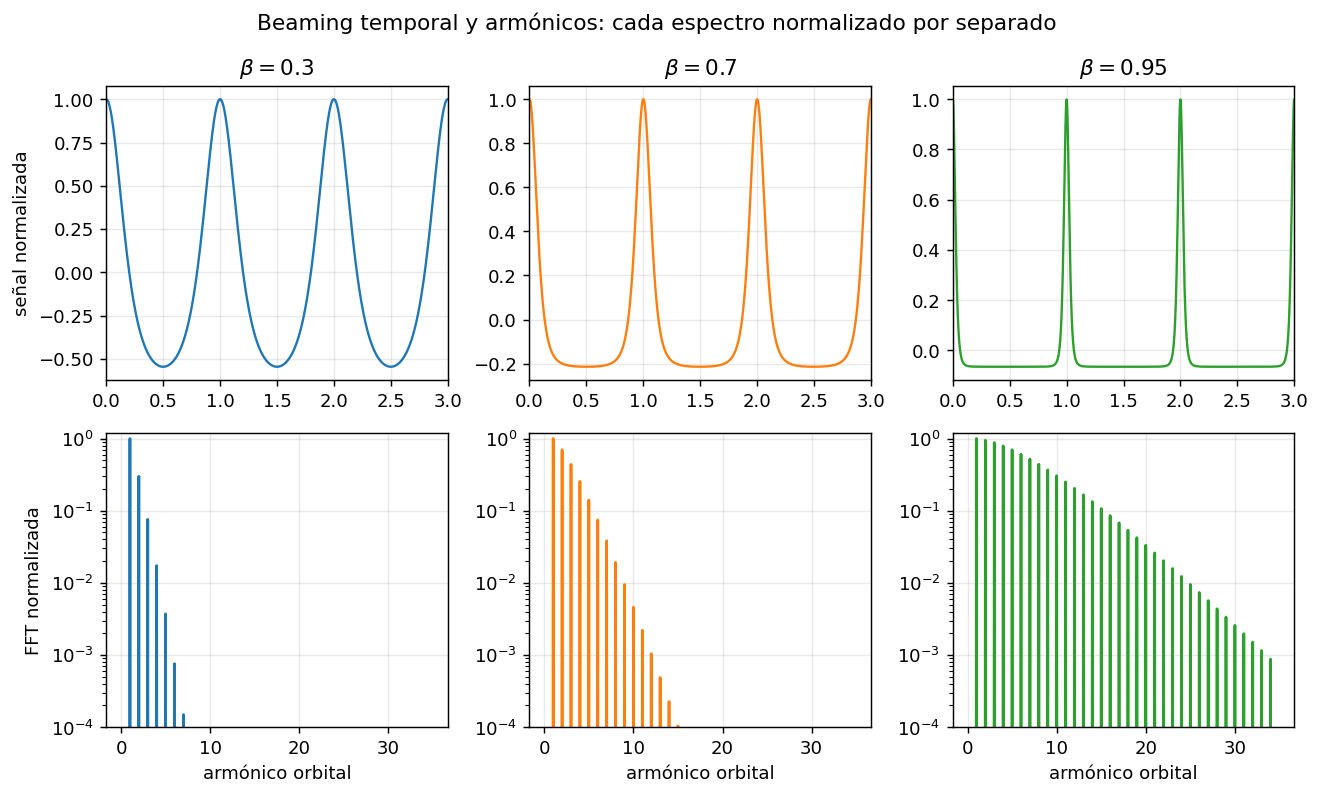

In [7]:
N = 4096
periods = 12
tsig = np.linspace(0, periods*2*np.pi, N, endpoint=False)

def observed_signal(beta):
    ndotb = beta * np.cos(tsig)
    raw = (1 - beta**2) / np.maximum(1 - ndotb, 1e-8)**3
    return raw - raw.mean()

betas_fft = [0.3, 0.7, 0.95]
fig, axs = plt.subplots(2, len(betas_fft), figsize=(10.2, 6.2), sharex="row")
for col, beta in enumerate(betas_fft):
    sig = observed_signal(beta)
    axs[0, col].plot(tsig/(2*np.pi), sig/sig.max(), lw=1.3, color=f"C{col}")
    freq = np.fft.rfftfreq(N, d=(tsig[1]-tsig[0])/(2*np.pi))
    amp = np.abs(np.fft.rfft(sig))
    amp /= amp.max()  # normalize each beta separately to compare harmonic reach
    mask = (freq > 0) & (freq < 35)
    axs[1, col].semilogy(freq[mask], amp[mask], lw=1.5, color=f"C{col}")
    axs[0, col].set_title(fr"$\beta={beta}$")
    axs[0, col].set_xlim(0, 3)
    axs[1, col].set_ylim(1e-4, 1.2)
    axs[1, col].set_xlabel("armónico orbital")
axs[0,0].set_ylabel("señal normalizada")
axs[1,0].set_ylabel("FFT normalizada")
fig.suptitle("Beaming temporal y armónicos: cada espectro normalizado por separado")
fig.tight_layout()
savefig("fft_harmonics_beaming.png")
plt.show()

## 9. Apéndice: órdenes de magnitud CRT vs sincrotrón real

Para electrones, $m_ec^2\simeq 511\,\mathrm{keV}$. Un CRT de decenas de keV apenas entra en régimen relativista leve. Un sincrotrón o acelerador de MeV/GeV alcanza $\gamma$ mucho mayor, por eso la radiación de curvatura puede ser intensa y direccional.

Comparación con B de referencia = 0.01 T
energía       gamma     beta    P/P(20keV)     f_c aproximada
  20 keV:    1.039   0.2719     1.000e+00     4.534e+08 Hz
  30 keV:    1.059   0.3284     2.293e+00     4.706e+08 Hz
  50 keV:    1.098   0.4127     6.615e+00     5.061e+08 Hz
 100 keV:    1.196   0.5482     2.899e+01     6.003e+08 Hz
   1 MeV:    2.957   0.9411     9.414e+03     3.671e+09 Hz
   1 GeV: 1957.947   1.0000     2.307e+15     1.610e+15 Hz


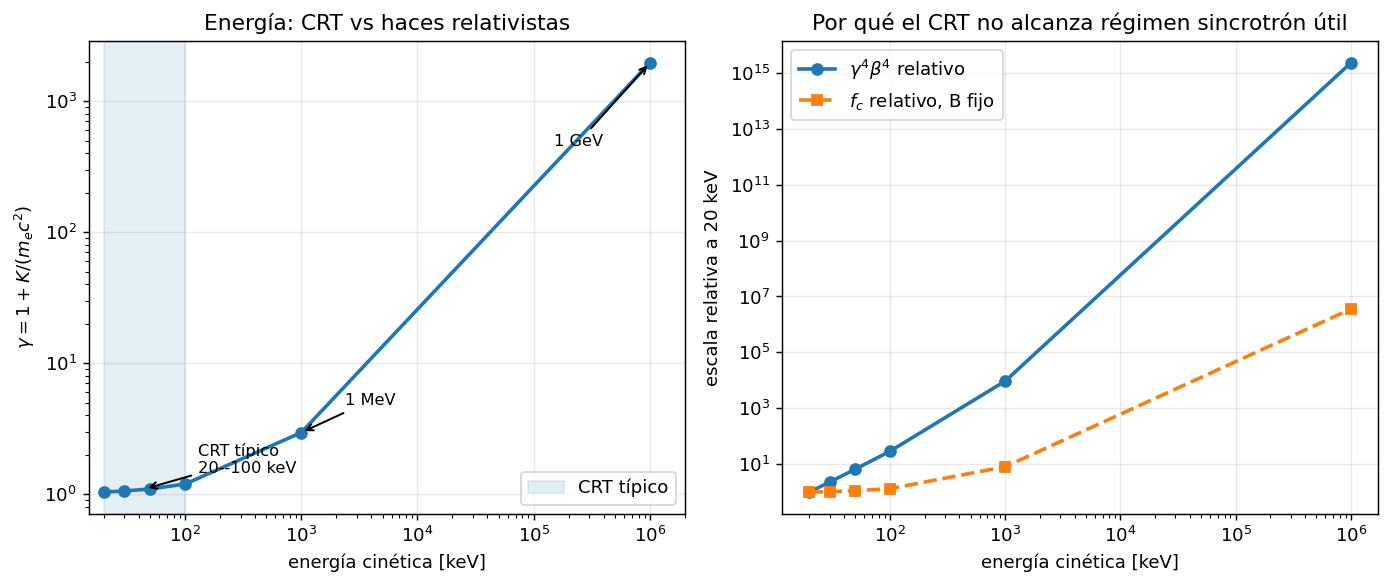

In [8]:
energies_keV = np.array([20, 30, 50, 100, 1e3, 1e6])
mc2_keV = 511.0
gamma_E = 1 + energies_keV/mc2_keV
beta_E = np.sqrt(1 - 1/gamma_E**2)

# For the same bending radius, synchrotron-like radiated power scales as gamma^4 beta^4.
power_scale = gamma_E**4 * beta_E**4
power_scale /= power_scale[0]

# For a representative magnetic field, estimate cyclotron/orbital and critical frequencies.
# omega_B = eB/(gamma m), omega_c ~ (3/2) gamma^3 omega_B = (3/2) gamma^2 eB/m.
e_over_m = 1.75882001076e11  # C/kg = rad s^-1 T^-1
B_ref = 0.01  # tesla, modest external/lab field scale
omega_orb = e_over_m * B_ref / gamma_E
omega_crit = 1.5 * gamma_E**3 * omega_orb
freq_crit = omega_crit / (2*np.pi)

print("Comparación con B de referencia = 0.01 T")
print("energía       gamma     beta    P/P(20keV)     f_c aproximada")
for E, g, b, ps, fc in zip(energies_keV, gamma_E, beta_E, power_scale, freq_crit):
    label = f"{E:g} keV" if E < 1e3 else ("1 MeV" if E == 1e3 else "1 GeV")
    print(f"{label:>8}: {g:8.3f}  {b:7.4f}  {ps:12.3e}  {fc:12.3e} Hz")

fig, axs = plt.subplots(1, 2, figsize=(10.8,4.6))
axs[0].semilogx(energies_keV, gamma_E, "o-", lw=2)
axs[0].set_yscale("log")
axs[0].axvspan(20, 100, color="tab:blue", alpha=0.12, label="CRT típico")
axs[0].annotate("CRT típico\n20--100 keV", xy=(45, gamma_E[2]), xytext=(130, 1.45),
                arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
axs[0].annotate("1 MeV", xy=(1e3, gamma_E[4]), xytext=(2.4e3, 4.8),
                arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
axs[0].annotate("1 GeV", xy=(1e6, gamma_E[5]), xytext=(1.5e5, 450),
                arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
axs[0].set_xlabel("energía cinética [keV]")
axs[0].set_ylabel(r"$\gamma = 1 + K/(m_ec^2)$")
axs[0].set_title("Energía: CRT vs haces relativistas")
axs[0].set_xlim(15, 2e6)
axs[0].legend(loc="lower right")

axs[1].loglog(energies_keV, power_scale, "o-", lw=2, label=r"$\gamma^4\beta^4$ relativo")
axs[1].loglog(energies_keV, freq_crit/freq_crit[0], "s--", lw=2, label=r"$f_c$ relativo, B fijo")
axs[1].set_xlabel("energía cinética [keV]")
axs[1].set_ylabel("escala relativa a 20 keV")
axs[1].set_title("Por qué el CRT no alcanza régimen sincrotrón útil")
axs[1].legend()
fig.tight_layout()
savefig("crt_vs_synchrotron_gamma.png")
plt.show()

## 10. Apéndice visual para la propuesta experimental

Esta figura pertenece conceptualmente a la propuesta con CRT. Se genera aquí solo para mantener reproducible la carpeta de figuras. No representa emisión sincrotrón; representa diagnóstico por deflexión del haz en una pantalla.

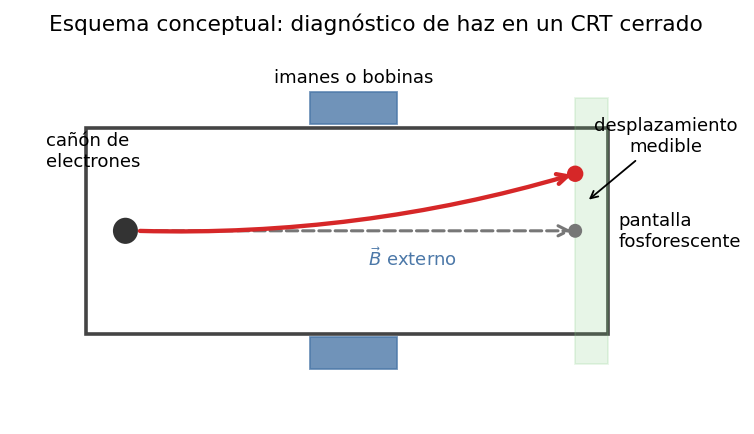

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")
ax.add_patch(Rectangle((1, 1.15), 7.2, 2.7, fill=False, lw=2, edgecolor="#444"))
ax.add_patch(Rectangle((7.75, 0.75), 0.45, 3.5, fill=True, alpha=0.18, color="#7fc97f"))
ax.text(8.35, 2.5, "pantalla\nfosforescente", va="center")
ax.add_patch(Circle((1.55, 2.5), 0.16, color="#333"))
ax.text(0.45, 3.35, "cañón de\nelectrones", ha="left")
ax.add_patch(FancyArrowPatch((1.7,2.5),(7.75,2.5), arrowstyle="->", mutation_scale=14, lw=1.7, color="#777", linestyle="--"))
ax.add_patch(FancyArrowPatch((1.7,2.5),(7.75,3.25), arrowstyle="->", mutation_scale=14, lw=2.4, color="#d62728", connectionstyle="arc3,rad=0.08"))
ax.scatter([7.75,7.75],[2.5,3.25], s=[45,65], c=["#777","#d62728"])
ax.annotate("desplazamiento\nmedible", xy=(7.9,2.88), xytext=(9.0,3.55), arrowprops=dict(arrowstyle="->"), ha="center")
ax.add_patch(Rectangle((4.1,3.9),1.2,0.42, color="#4c78a8", alpha=0.8))
ax.add_patch(Rectangle((4.1,0.68),1.2,0.42, color="#4c78a8", alpha=0.8))
ax.text(4.7,4.45,"imanes o bobinas", ha="center")
ax.text(4.9,2.05, r"$\vec B$ externo", color="#4c78a8")
ax.set_title("Esquema conceptual: diagnóstico de haz en un CRT cerrado")
savefig("crt_schematic.png")
plt.show()

## 11. Discusión y conclusiones

- La fórmula angular relativista muestra una transición clara: de patrones amplios a lóbulos estrechos cuando $\gamma$ crece.
- El barrido cuantitativo confirma que el máximo angular aumenta y el ancho principal baja aproximadamente con la escala $1/\gamma$.
- La solución numérica del tiempo retardado evidencia que el campo observado corresponde a una posición anterior de la carga, no a la posición instantánea.
- La FFT simplificada ilustra por qué el movimiento relativista curvo genera contenido armónico más rico.
- El cálculo de órdenes de magnitud separa la física del notebook de la propuesta experimental: un CRT sirve como analogía de diagnóstico por deflexión, no como fuente medible de sincrotrón.